In [18]:
from src.main import relight_content_image
from src.image_util import normalized_linear_to_srgb
from src.isd_estimation import ResNet50UNet
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2


def read_16bit_img(img_path):
    img = imread(img_path)
    img_bit_depth = np.iinfo(img.dtype).bits
    img = img / (2**img_bit_depth - 1)
    return img


def plot_roi(norm_linear_img, roi):
    y, x, h, w = roi  # row, col, height, width
    srgb_img = normalized_linear_to_srgb(norm_linear_img)
    srgb_roi = srgb_img[y : y + h, x : x + w]
    plt.figure()
    plt.imshow(srgb_roi)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# ISD model
isd_model_path = "weights/unet.pth"
isd_model = ResNet50UNet(
    in_channels=3,
    out_channels=3,
    pretrained=True,
    checkpoint=isd_model_path,
    se_block=True,
    dropout=0.0,
)

INFO: Initializing ResNet50UNet | in_channels=3, out_channels=3, pretrained=True, checkpoint=weights/unet.pth, se_block=True
INFO: Loading ResNet50 weights from checkpoint: weights/unet.pth


INFO: ResNet50UNet Parameter Summary (Top-Level Modules):
INFO: --------------------------------------------------------------------------------
INFO: in_conv                   | Total: 9536                 | Trainable: 9,536
INFO: maxpool                   | Total: 0                    | Trainable: 0
INFO: enc1                      | Total: 215808               | Trainable: 215,808
INFO: enc2                      | Total: 1219584              | Trainable: 1,219,584
INFO: enc3                      | Total: 7098368              | Trainable: 7,098,368
INFO: enc4                      | Total: 14964736             | Trainable: 14,964,736
INFO: up4                       | Total: 16551456             | Trainable: 16,551,456
INFO: up3                       | Total: 2959120              | Trainable: 2,959,120
INFO: up2                       | Total: 740232               | Trainable: 740,232
INFO: up1                       | Total: 148420               | Trainable: 148,420
INFO: up0            

**Inputs** 

Run one of the cells below to use a specific pair of content and style

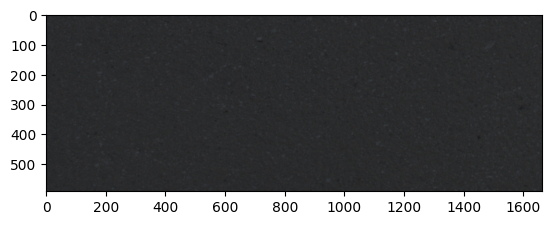

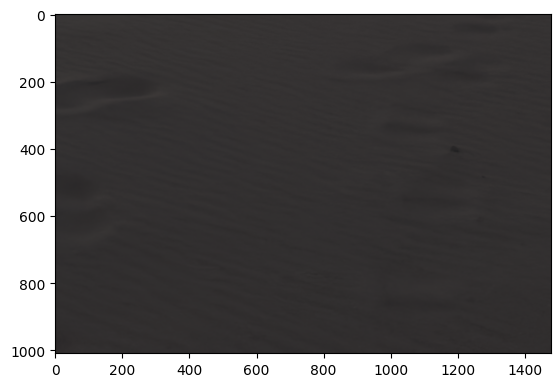

In [13]:
content_path = "data/RAWAE/raw_maxwell_2023_05_26_ - 001123.tiff"
style_path = "data/custom/beach_sunset.tiff"

content_img = read_16bit_img(content_path)
# content_roi = (1944, 725, 314, 586)  # row, col, h, w  (for bucket)
content_roi = (2749, 522, 591, 1664)
plot_roi(content_img, content_roi)

style_img = read_16bit_img(style_path)
style_roi = (4383, 5926, 1009, 1477)  # row, col, h, w
plot_roi(style_img, style_roi)


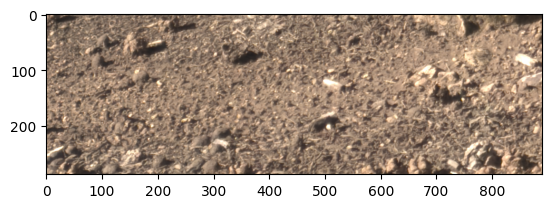

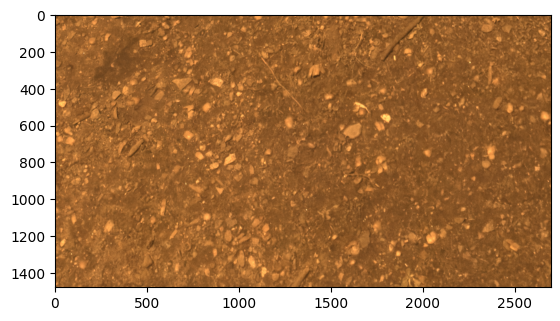

In [ ]:
content_path = "data/custom/forest_day.tiff"
style_path = "data/custom/lamppost_streetlight.tiff"

content_img = read_16bit_img(content_path)
content_roi = (5298, 357, 287, 890)
plot_roi(content_img, content_roi)

style_img = read_16bit_img(style_path)
style_roi = (6004, 697, 1479, 2696)  # row, col, h, w
plot_roi(style_img, style_roi)

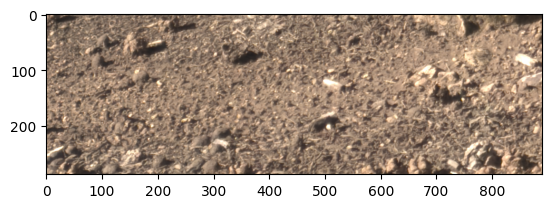

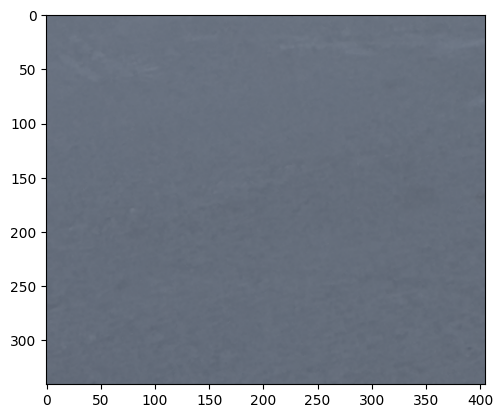

In [ ]:
content_path = "data/custom/forest_day.tiff"
style_path = "data/adh/IMG_8216.tiff"

content_img = read_16bit_img(content_path)
content_roi = (5298, 357, 287, 890)
plot_roi(content_img, content_roi)

style_img = read_16bit_img(style_path)
style_roi = (3204, 839, 341, 405)  # row, col, h, w
plot_roi(style_img, style_roi)

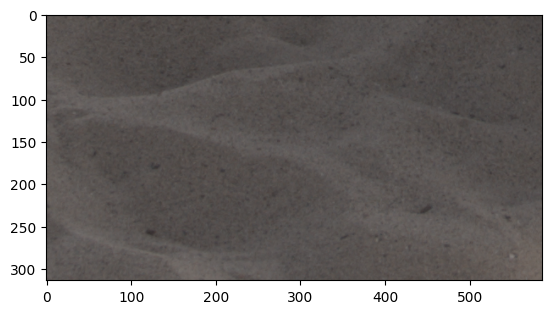

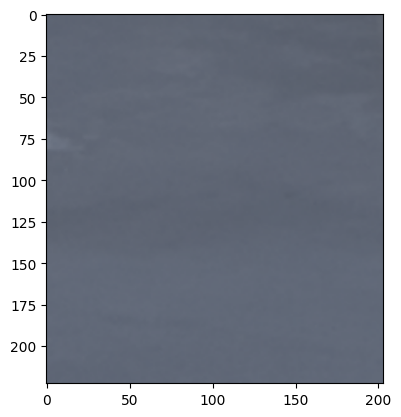

In [ ]:
content_path = "data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff"
style_path = "data/adh/IMG_8221.tiff"

content_img = read_16bit_img(content_path)
content_roi = (1944, 725, 314, 586)  # row, col, h, w  (for bucket)
plot_roi(content_img, content_roi)

style_img = read_16bit_img(style_path)
style_roi = (2308, 734, 223, 203)  # row, col, h, w
plot_roi(style_img, style_roi)

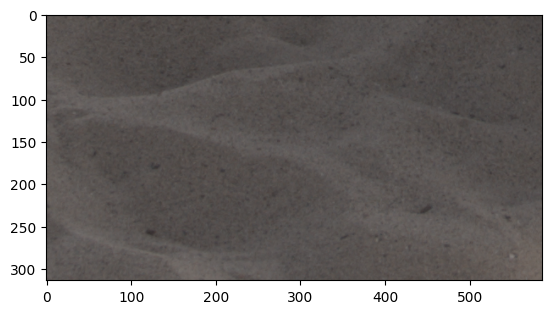

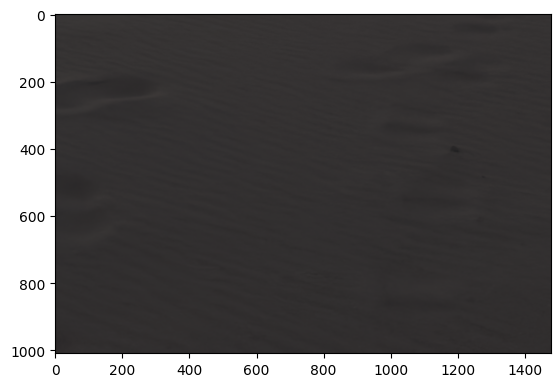

In [ ]:
content_path = "data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff"
style_path = "data/custom/beach_sunset.tiff"
content_img = read_16bit_img(content_path)
content_roi = (1944, 725, 314, 586)  # row, col, h, w  (for bucket)
plot_roi(content_img, content_roi)
style_img = read_16bit_img(style_path)
style_roi = (4383, 5926, 1009, 1477)  # row, col, h, w
plot_roi(style_img, style_roi)


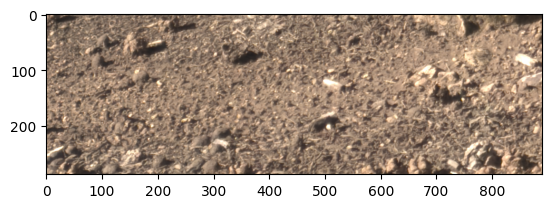

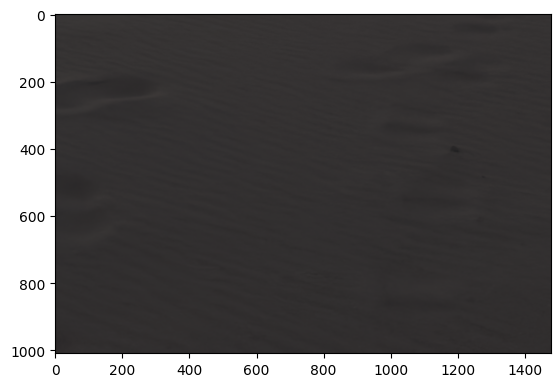

In [ ]:
content_path = "data/custom/forest_day.tiff"
style_path = "data/custom/beach_sunset.tiff"

content_img = read_16bit_img(content_path)
content_roi = (5298, 357, 287, 890)
plot_roi(content_img, content_roi)


style_img = read_16bit_img(style_path)
style_roi = (4383, 5926, 1009, 1477)  # row, col, h, w
plot_roi(style_img, style_roi)


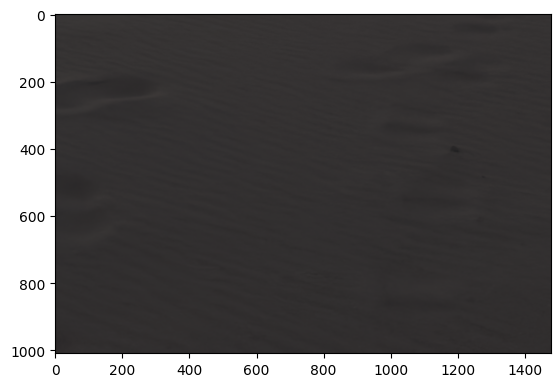

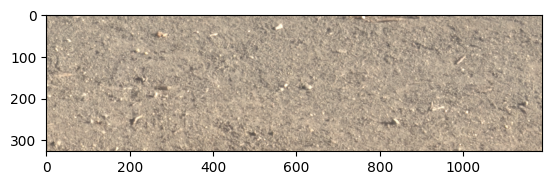

In [ ]:
content_path = "data/custom/beach_sunset.tiff"
style_path = "data/custom/bench_day.tiff"

content_img = read_16bit_img(content_path)
content_roi = (4383, 5926, 1009, 1477)  # row, col, h, w
plot_roi(content_img, content_roi)

style_img = read_16bit_img(style_path)
style_roi = (5716, 2451, 327, 1190)  # row, col, h, w
plot_roi(style_img, style_roi)


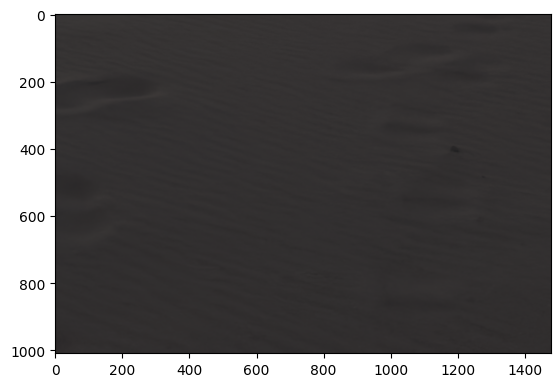

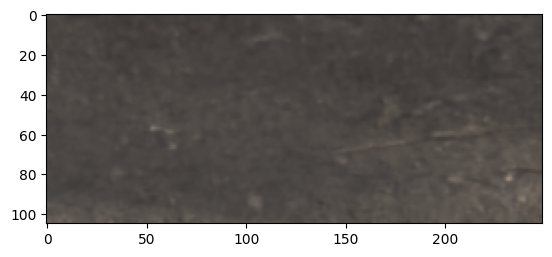

In [ ]:
content_path = "data/custom/beach_sunset.tiff"
style_path = "data/custom/bench_day.tiff"

content_img = read_16bit_img(content_path)
content_roi = (4383, 5926, 1009, 1477)  # row, col, h, w
plot_roi(content_img, content_roi)

style_img = read_16bit_img(style_path)
style_roi = (5258, 2202, 105, 249)  # row, col, h, w
plot_roi(style_img, style_roi)


**Relight**

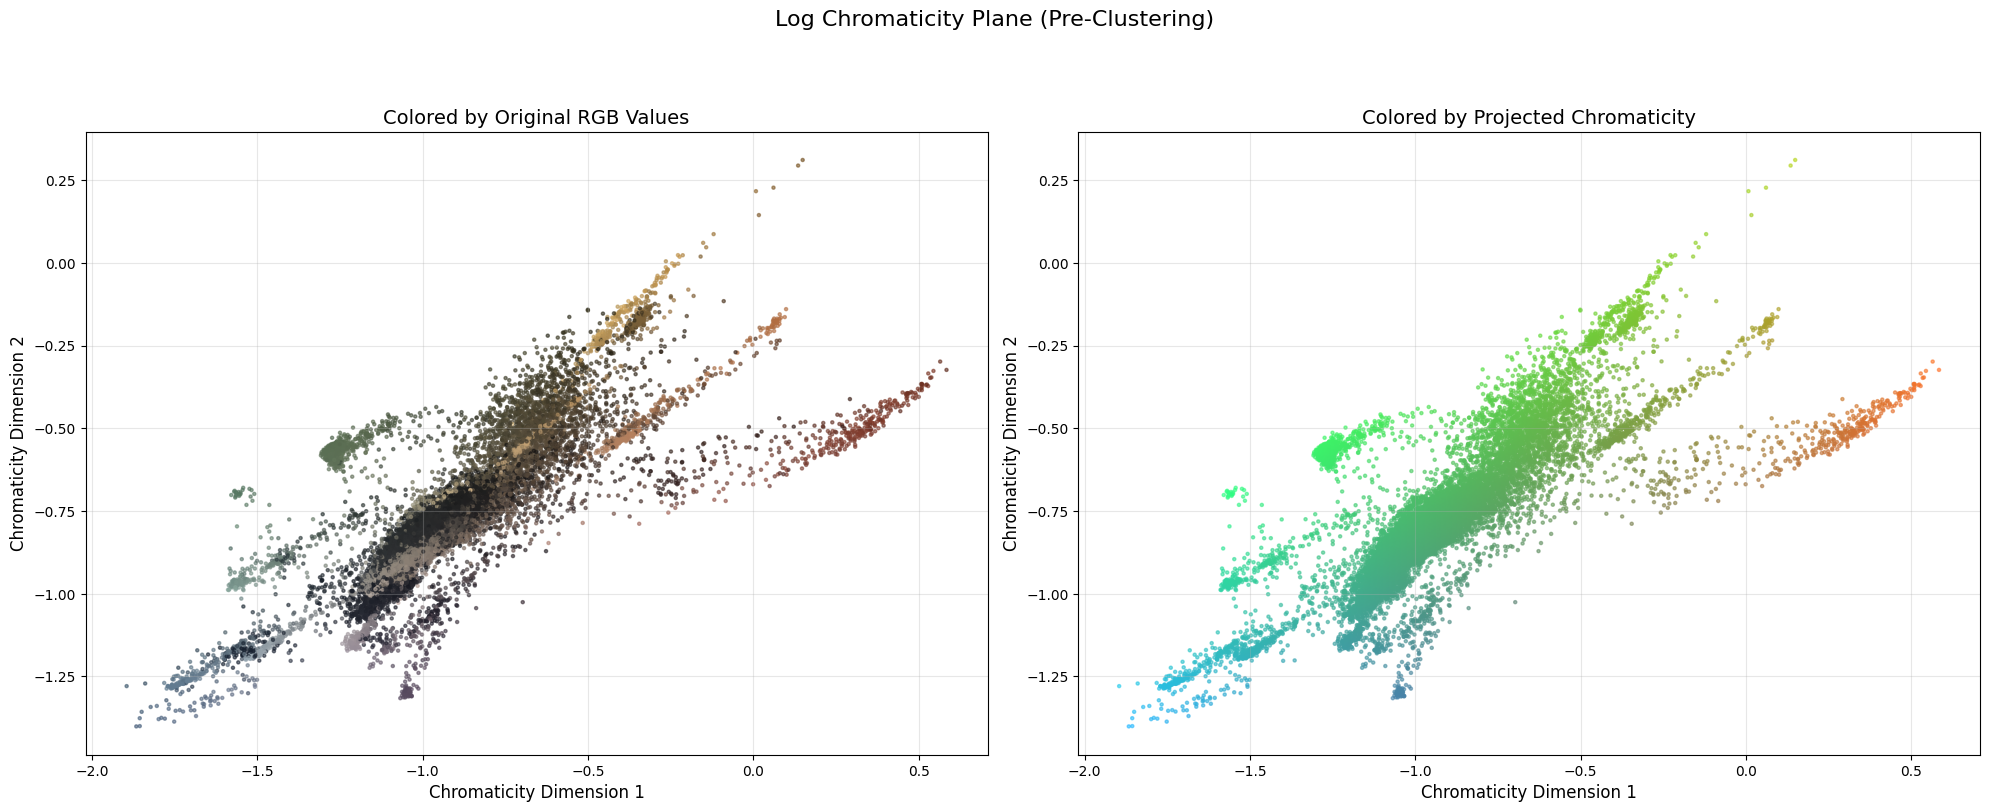

INFO: K-Means clustering: 3 clusters


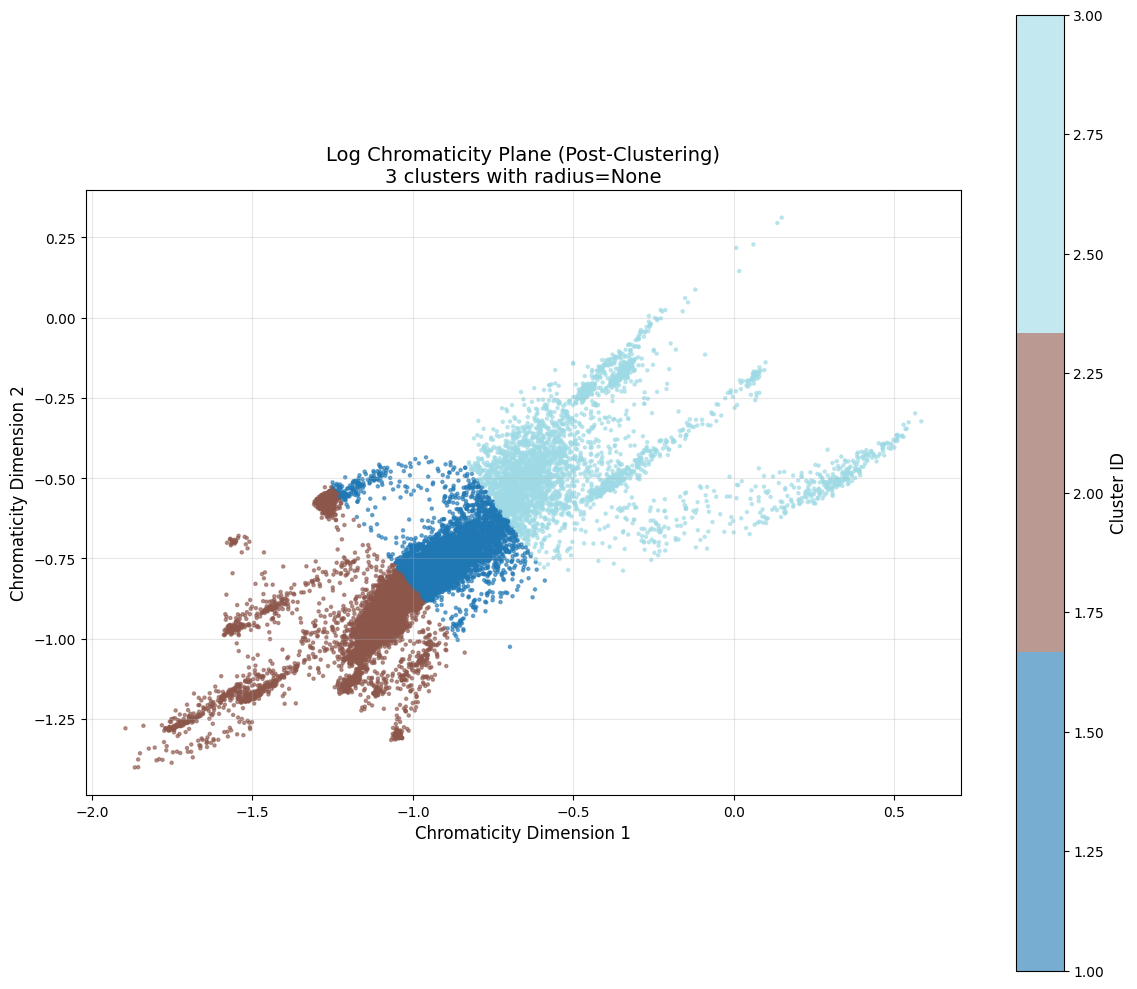

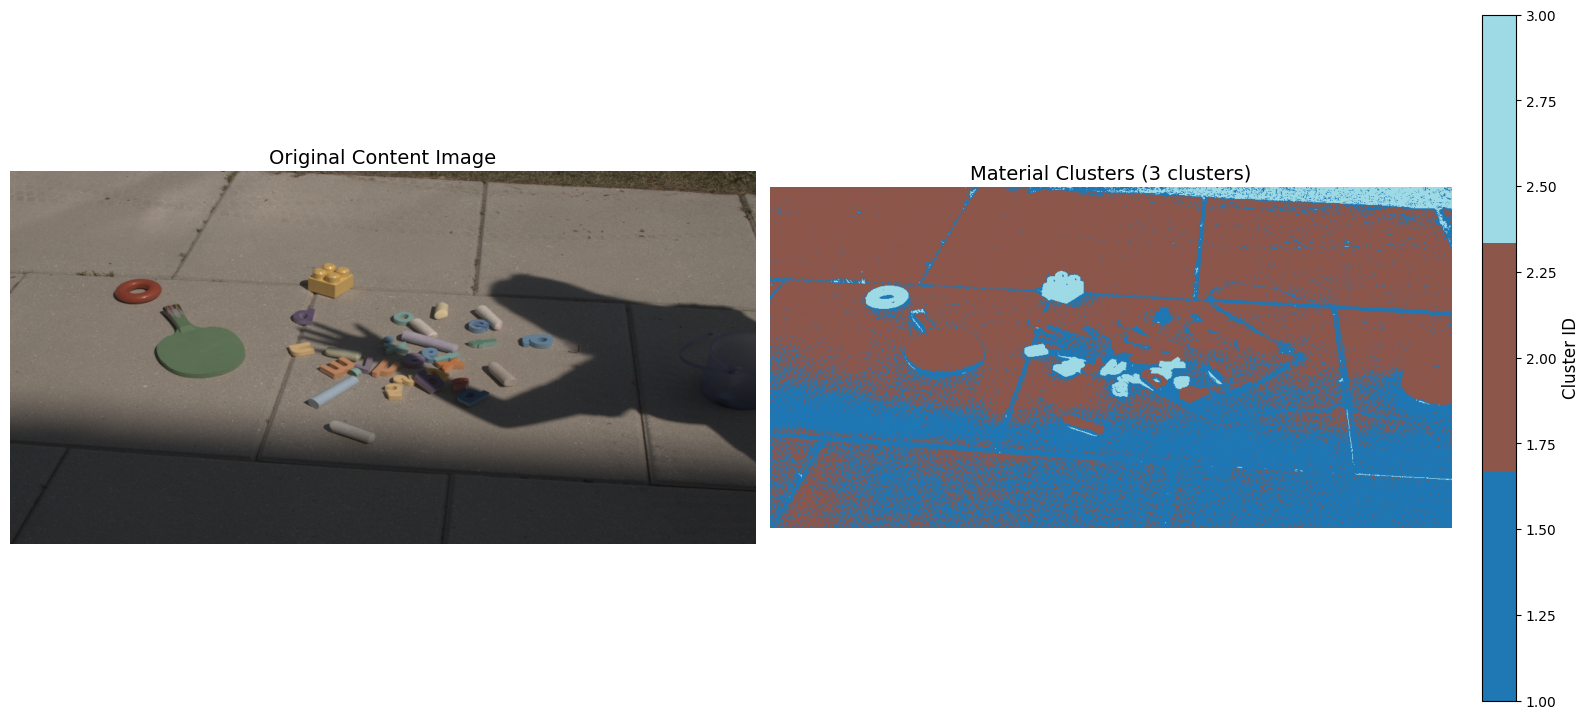

INFO: Estimated illumination vector norm 4.514839485279083
INFO: Estimated dark and bright points for 3 material clusters
INFO: Average Style ISD: [0.66621697 0.5875498  0.4592823 ]. Average Content ISD: [0.63817793 0.5843365  0.50127804]
INFO: Pivoted all pixels for each material cluster.


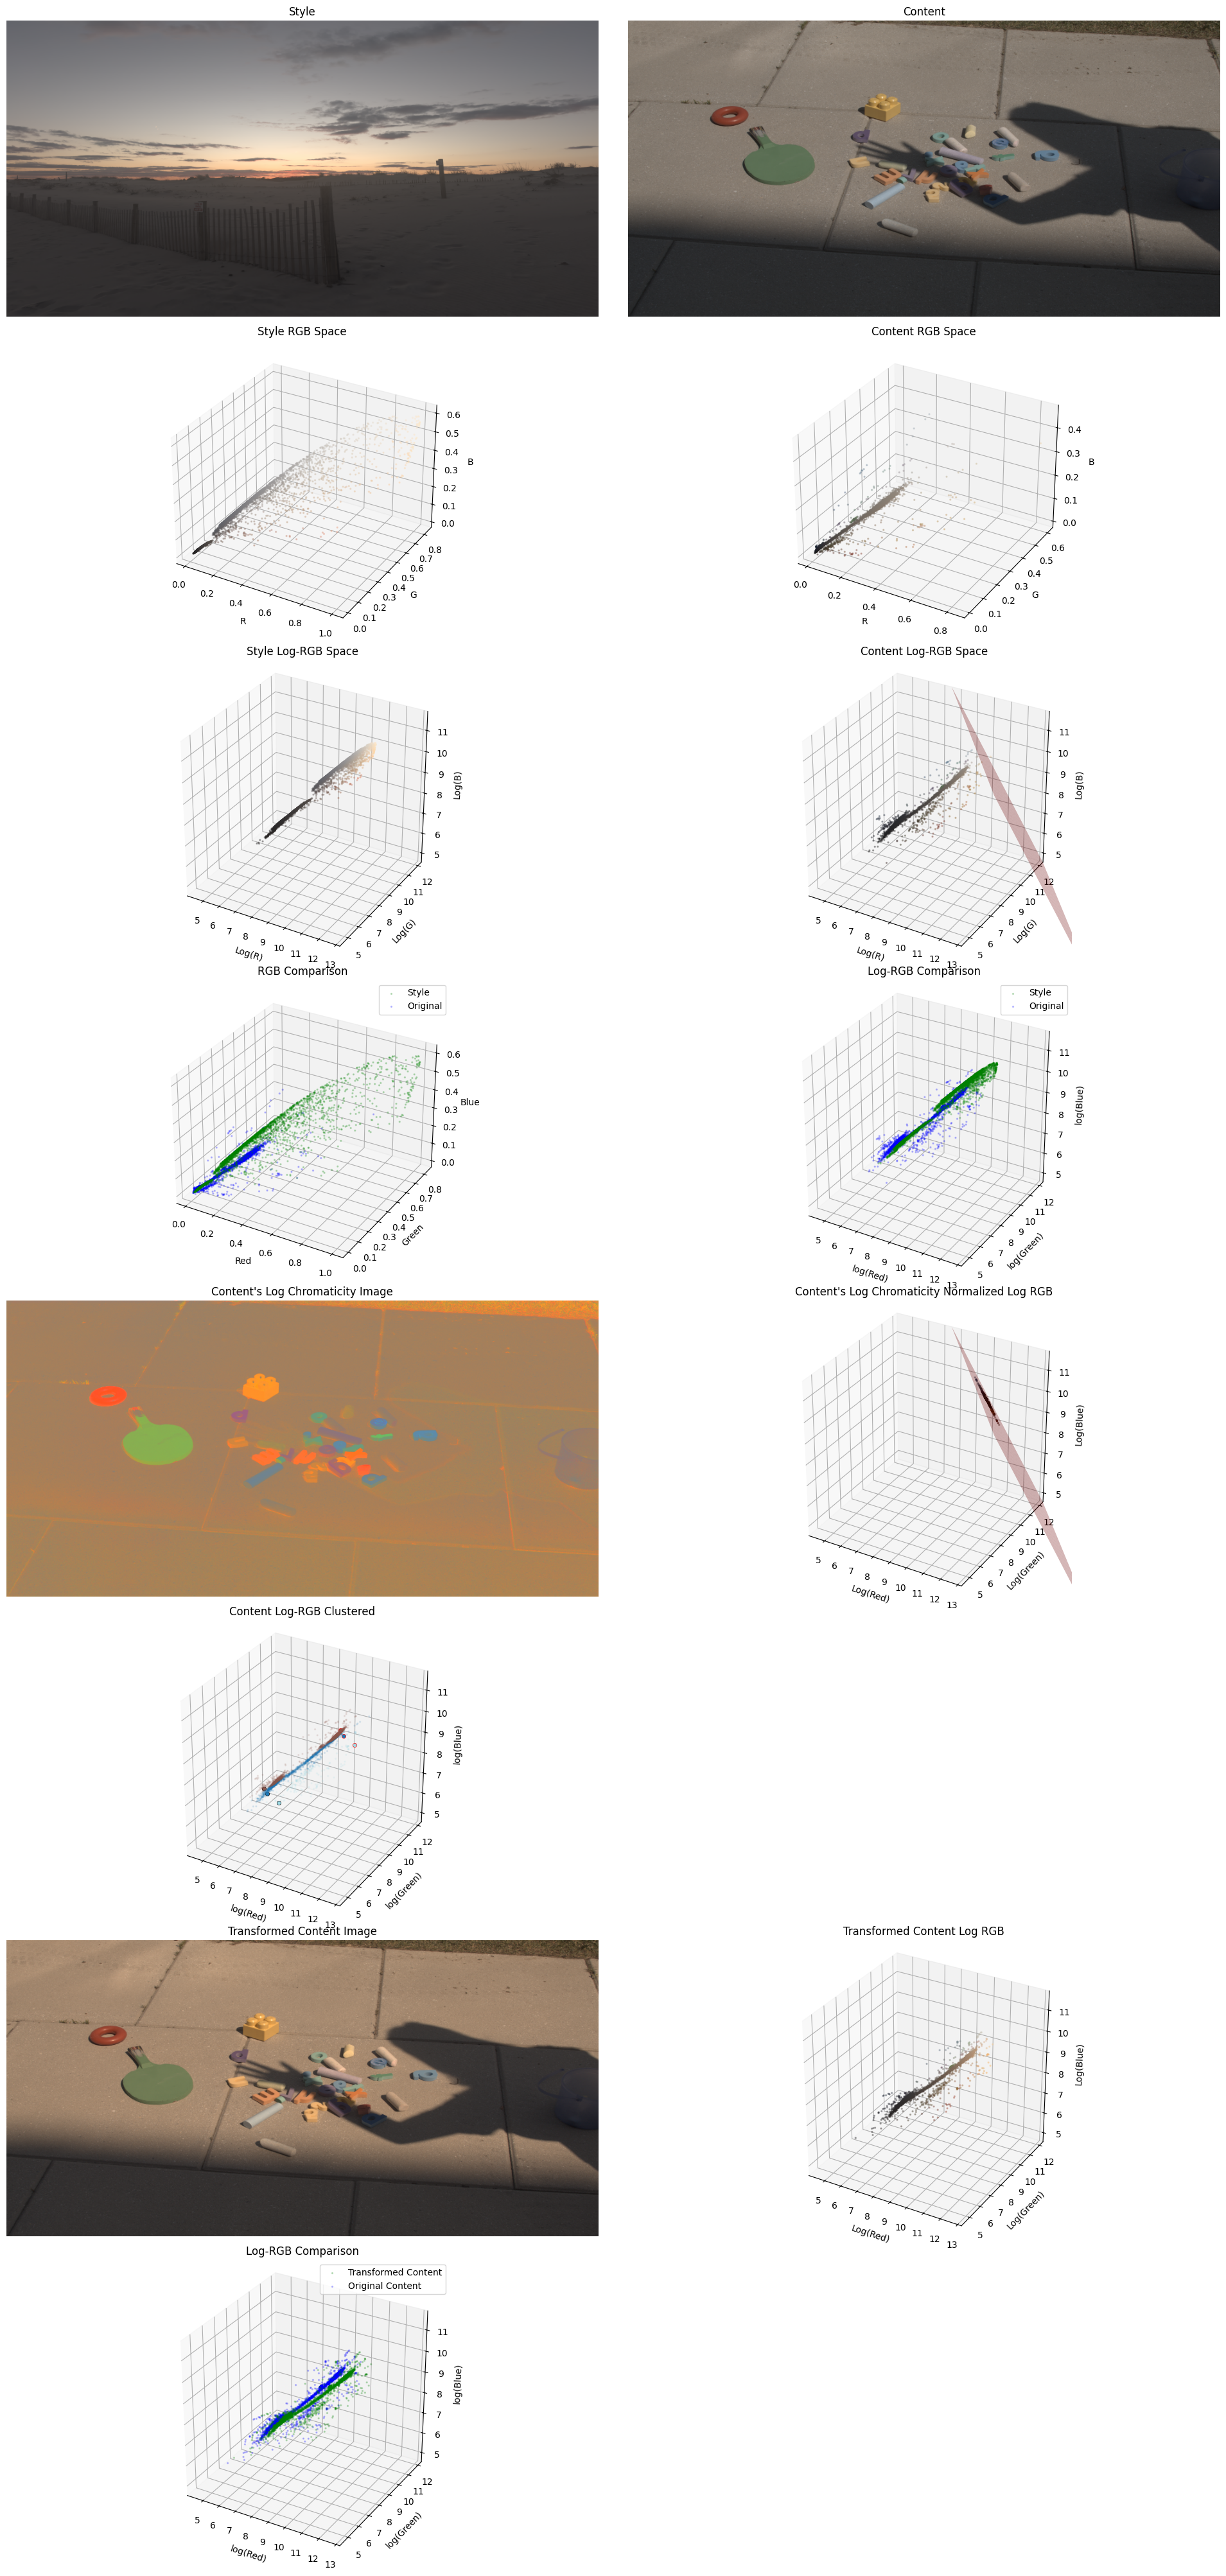

In [20]:
tf_linear_img = relight_content_image(
    content_path=content_path,
    style_path=style_path,
    isd_model=isd_model,
    output_path="data/target.png",
    resize_scale=1 / 6,
    clustering_method="kmeans",  # greedy, kmeans
    view_isd=False,  # see log rgb perpendicular to isd. should look similar to log chroma plane from max.
    n_clusters=3,
    bin_radius=0.2,
    rot_percent=100.0,  # either change this or rot_angle, not both.
    # rot_angle=np.deg2rad(-20.0),
    # log_transl=np.ones(3) * -1.0,
    length_scale=1.0,
    always_use_global_illum_norm=True,
    style_roi=style_roi,
    content_roi=content_roi,
)